# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

In [137]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 14.9 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [138]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh
import pandas as pd

rng = np.random.default_rng(0)

In [139]:
d = 40
k = 8
sigma = 0.1
n_list = [1500, 5000, 10000]
threshold_list = [0.1, 0.5, 0.9]

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [140]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

In [ ]:
def sample(W, n):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

results = []

for n_samples in n_list:
    #Generate samples and empirical covariances
    #Generating only one sample matrix
    X_lr = sample(W0 + DeltaW_lr, n_samples)
    X_dense = sample(W0 + DeltaW_dense, n_samples)
    S_lr = (X_lr.T @ X_lr) / n_samples
    S_dense = (X_dense.T @ X_dense) / n_samples

    # Eigenvalues
    eig0 = eigvalsh(Sigma0)
    eig_lr = eigvalsh(S_lr)
    eig_dense = eigvalsh(S_dense)

    for thresh in threshold_list:
        rel_change_lr = np.abs(eig_lr - eig0) / eig0
        rel_change_dense = np.abs(eig_dense - eig0) / eig0

        num_sig_lr = np.sum(rel_change_lr > thresh)
        num_sig_dense = np.sum(rel_change_dense > thresh)

        results.append({
            "n_samples": n_samples,
            "threshold": thresh,
            "num_sig_lowrank": num_sig_lr,
            "num_sig_diffuse": num_sig_dense
        })

# Convert results to a DataFrame and display as a table
df_results = pd.DataFrame(results)
print(df_results)

   n_samples  threshold  num_sig_lowrank  num_sig_diffuse
0       1500        0.1               24               26
1       1500        0.5                3                8
2       1500        0.9                2                7
3       5000        0.1               11               17
4       5000        0.5                3                8
5       5000        0.9                2                7
6      10000        0.1                6               10
7      10000        0.5                3                8
8      10000        0.9                2                7


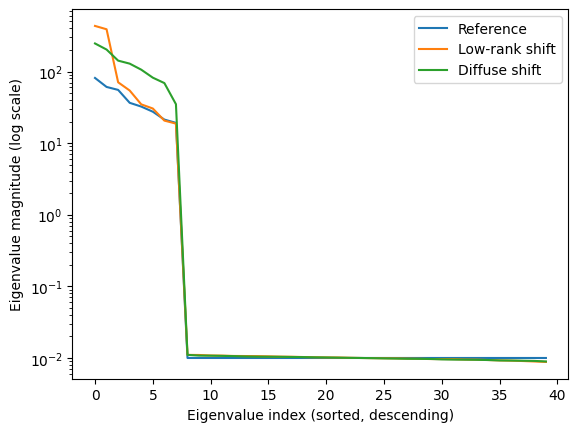

In [ ]:
eig0 = eigvalsh(Sigma0)
eig_lr = eigvalsh(S_lr)
eig_dense = eigvalsh(S_dense)

plt.semilogy(eig0[::-1], label='Reference')
plt.semilogy(eig_lr[::-1], label='Low-rank shift')
plt.semilogy(eig_dense[::-1], label='Diffuse shift')
plt.legend()

plt.xlabel("Eigenvalue index (sorted, descending)")
plt.ylabel("Eigenvalue magnitude (log scale)")

plt.show()

1. In the low-rank case, how many eigenvalues change substantially, and how does this number relate to the rank of the coefficient modification? 

I modified the code above to output a table that compares the number of eigenvalues that change substantially under varying thresholds and numbers of samples (n). The number of eigenvalues that change substantially in the low-rank case decreases as the number of samples increases and/or as the threshold becomes more stringent. For example: With n=1500 and threshold 0.1, 21 eigenvalues change, with n=10000 and threshold 0.1, only 9 eigenvalues change, and with threshold 0.9 (very strict threshold), only 2 eigenvalues change, regardless of sample size.

This aligns with expectations because the DeltaW_lr has rank 2, meaning in theory that it can only introduce significant variance in at most 2 directions. The larger numbers observed with lower sample sizes or lower thresholds could be due to sampling noise, which makes additional eigenvalues appear to change slightly. As the threshold is increased or the sample size grows, the number of significantly changed eigenvalues converges to 2, which matches the rank of the low-rank modification.

2. In the diffuse case, why are many eigenvalues affected, even though the overall magnitude of the change is the same?

In the diffuse case, a dense and approximately full-rank modification (nearly k=8) of W was applied with the same magnitude as the low-rank change. This caused most eigenvalues to change substantially. The diffuse change has components along nearly all directions of W-space, and as a result it affects the covariance in many geometric directions as opposed to being concentrated along a few dominating variance directions. As a result, the effect is distributed across many eigenvalues, even though the total magnitude of the perturbation is equal to the low-rank case.


3. How do these observations illustrate the idea that matrix rank limits the number of variance directions that can change?

 In the low-rank case, the modification mostly affects only a few eigenvalues corresponding to the directions with the dominant variance, whereas in the diffuse case the changes are distributed across most of the eigenvalues. As a result, the eigenvalue spectrum provides a direct measure of how matrix rank limits the geometric directions along which variance can shift. 